<a href="https://colab.research.google.com/github/vneelima44/fairlens/blob/main/notebooks/fairlens_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

In [ ]:
# =============================================================================
# HMDA 2019 NY — Load Dataset from CFPB API
# =============================================================================

import pandas as pd
import numpy as np
import requests
import io
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# OPTION 1 — Load directly into pandas from URL (recommended for Colab)
# =============================================================================

URL = "https://ffiec.cfpb.gov/v2/data-browser-api/view/csv?states=NY&years=2021&actions_taken=1,2,3,7,8"

print('Loading HMDA 2020 NY dataset from CFPB API...')
print('(This may take 1-2 minutes depending on connection speed)')

df_raw_2019 = pd.read_csv(URL, low_memory=False)

print(f'\n✅ Loaded successfully')
print(f'   Shape: {df_raw_2019.shape[0]:,} rows × {df_raw_2019.shape[1]} columns')
print(f'   Memory: {df_raw_2019.memory_usage(deep=True).sum() / 1e6:.1f} MB')

# =============================================================================
# OPTION 2 — If Option 1 times out, save to Drive first
# Uncomment and run this block instead
# =============================================================================

# import subprocess
# subprocess.run([
#     'curl', '-L',
#     'https://ffiec.cfpb.gov/v2/data-browser-api/view/csv?states=NY&years=2019&actions_taken=1,2,3,7,8',
#     '-o', '/content/drive/MyDrive/hmda_2019_ny.csv'
# ])
# df_raw_2019 = pd.read_csv('/content/drive/MyDrive/hmda_2019_ny.csv', low_memory=False)
# print(f'Loaded from Drive: {df_raw_2019.shape}')

# =============================================================================
# QUICK SANITY CHECK
# =============================================================================
print(f'\n  Columns: {df_raw_2019.shape[1]}')
print(f'\n  Action taken distribution:')
print(df_raw_2019['action_taken'].value_counts().sort_index().to_string())

print(f'\n  First 5 columns: {df_raw_2019.columns[:5].tolist()}')
print(f'\n  Sample column names (all):')
for i, col in enumerate(df_raw_2019.columns):
    print(f'    {i+1:>3}. {col}')

Loading HMDA 2020 NY dataset from CFPB API...
(This may take 1-2 minutes depending on connection speed)

✅ Loaded successfully
   Shape: 600,611 rows × 99 columns
   Memory: 1172.5 MB

  Columns: 99

  Action taken distribution:
action_taken
1    474930
2     19549
3    105159
7       242
8       731

  First 5 columns: ['activity_year', 'lei', 'derived_msa-md', 'state_code', 'county_code']

  Sample column names (all):
      1. activity_year
      2. lei
      3. derived_msa-md
      4. state_code
      5. county_code
      6. census_tract
      7. conforming_loan_limit
      8. derived_loan_product_type
      9. derived_dwelling_category
     10. derived_ethnicity
     11. derived_race
     12. derived_sex
     13. action_taken
     14. purchaser_type
     15. preapproval
     16. loan_type
     17. loan_purpose
     18. lien_status
     19. reverse_mortgage
     20. open-end_line_of_credit
     21. business_or_commercial_purpose
     22. loan_amount
     23. loan_to_value_ratio
    

In [ ]:
import pandas as pd
import numpy as np

print('=' * 70)
print('HMDA 2019 NY — Full Missing Value Analysis')
print('=' * 70)
print(f'\n  Total rows:    {len(df_raw_2019):,}')
print(f'  Total columns: {df_raw_2019.shape[1]}')

# Check both NaN AND HMDA coded missing values
CODED_MISSING = ['Exempt', 'NA', '1111', '9999', 'Inapplicable', 'Not applicable']

rows = []
for col in df_raw_2019.columns:
    n_null    = df_raw_2019[col].isnull().sum()
    n_coded   = df_raw_2019[col].astype(str).isin(CODED_MISSING).sum()
    n_total   = n_null + n_coded
    pct       = n_total / len(df_raw_2019) * 100
    rows.append({
        'column':        col,
        'null_count':    n_null,
        'coded_missing': n_coded,
        'total_missing': n_total,
        'missing_pct':   round(pct, 2),
        'dtype':         df_raw_2019[col].dtype,
        'n_unique':      df_raw_2019[col].nunique()
    })

missing_df = pd.DataFrame(rows).sort_values('missing_pct', ascending=False)

print(f'\n  {"Column":<50} {"NaN":>8} {"Coded":>8} {"Total%":>8} {"Unique":>8}')
print(f'  {"─"*85}')
for _, row in missing_df.iterrows():
    flag = ' ⚠️' if row['missing_pct'] > 50 else ''
    print(f'  {row["column"]:<50} {int(row["null_count"]):>8,} '
          f'{int(row["coded_missing"]):>8,} {row["missing_pct"]:>7.1f}%{flag} '
          f'{int(row["n_unique"]):>8}')

# Summary
print(f'\n  {"─"*50}')
print(f'  Columns >70% missing: {(missing_df["missing_pct"]>70).sum()}')
print(f'  Columns 30-70% missing: {((missing_df["missing_pct"]>=30) & (missing_df["missing_pct"]<=70)).sum()}')
print(f'  Columns <30% missing: {(missing_df["missing_pct"]<30).sum()}')
print(f'  Columns 0% missing: {(missing_df["missing_pct"]==0).sum()}')

HMDA 2019 NY — Full Missing Value Analysis

  Total rows:    600,611
  Total columns: 99

  Column                                                  NaN    Coded   Total%   Unique
  ─────────────────────────────────────────────────────────────────────────────────────
  applicant_ethnicity-5                               600,602        0   100.0% ⚠️        3
  co-applicant_ethnicity-4                            600,606        0   100.0% ⚠️        2
  co-applicant_ethnicity-5                            600,611        0   100.0% ⚠️        0
  applicant_ethnicity-4                               600,592        0   100.0% ⚠️        3
  co-applicant_race-5                                 600,601        0   100.0% ⚠️        5
  applicant_race-5                                    600,576        0   100.0% ⚠️       10
  co-applicant_race-4                                 600,556        0   100.0% ⚠️       13
  co-applicant_ethnicity-3                            600,461        0   100.0% ⚠️       

In [ ]:
# Remove columns with 100% missing (NaN only)
cols_100_missing = [col for col in df_raw_2019.columns
                    if df_raw_2019[col].isnull().mean() == 1.0]

print(f'Columns with 100% missing: {len(cols_100_missing)}')
print(cols_100_missing)

df_2019 = df_raw_2019.drop(columns=cols_100_missing)
print(f'\nShape after dropping: {df_2019.shape[0]:,} rows × {df_2019.shape[1]} columns')

Columns with 100% missing: 1
['co-applicant_ethnicity-5']

Shape after dropping: 600,611 rows × 98 columns


In [ ]:
# Remove columns with >99% missing
cols_99_missing = [col for col in df_2019.columns
                   if df_2019[col].isnull().mean() > 0.99]

print(f'Columns with >99% missing: {len(cols_99_missing)}')
for col in cols_99_missing:
    pct = df_2019[col].isnull().mean() * 100
    print(f'  {col:<50} {pct:.2f}%')

df_2019 = df_2019.drop(columns=cols_99_missing)
print(f'\nShape after dropping: {df_2019.shape[0]:,} rows × {df_2019.shape[1]} columns')

Columns with >99% missing: 15
  applicant_ethnicity-3                              99.92%
  applicant_ethnicity-4                              100.00%
  applicant_ethnicity-5                              100.00%
  co-applicant_ethnicity-3                           99.98%
  co-applicant_ethnicity-4                           100.00%
  applicant_race-3                                   99.68%
  applicant_race-4                                   99.98%
  applicant_race-5                                   99.99%
  co-applicant_race-3                                99.87%
  co-applicant_race-4                                99.99%
  co-applicant_race-5                                100.00%
  aus-4                                              99.92%
  aus-5                                              99.93%
  denial_reason-3                                    99.33%
  denial_reason-4                                    99.94%

Shape after dropping: 600,611 rows × 83 columns


In [ ]:
# Full missing % of remaining 83 columns — sorted
missing_remaining = pd.DataFrame({
    'missing_pct': df_2019.isnull().mean() * 100,
    'n_unique':    df_2019.nunique(),
    'dtype':       df_2019.dtypes
}).sort_values('missing_pct', ascending=False)

print(f'{"Column":<50} {"Missing%":>10} {"Unique":>8}')
print(f'{"─"*70}')
for col, row in missing_remaining.iterrows():
    flag = ' ⚠️' if row['missing_pct'] > 50 else ''
    print(f'{col:<50} {row["missing_pct"]:>9.1f}%{flag} {int(row["n_unique"]):>8}')

Column                                               Missing%   Unique
──────────────────────────────────────────────────────────────────────
co-applicant_ethnicity-2                                98.9% ⚠️        6
co-applicant_race-2                                     97.8% ⚠️       16
total_points_and_fees                                   97.6% ⚠️      513
aus-3                                                   97.5% ⚠️        4
multifamily_affordable_units                            97.2% ⚠️       68
applicant_ethnicity-2                                   97.0% ⚠️        6
denial_reason-2                                         96.4% ⚠️        9
prepayment_penalty_term                                 95.7% ⚠️        8
applicant_race-2                                        94.1% ⚠️       16
aus-2                                                   89.8% ⚠️        6
intro_rate_period                                       82.8% ⚠️       70
lender_credits                              

In [ ]:
# Drop all columns with >50% missing
cols_to_drop = [col for col in df_2019.columns
                if df_2019[col].isnull().mean() > 0.50]

print(f'Columns dropped (>50% missing): {len(cols_to_drop)}')
df_2019 = df_2019.drop(columns=cols_to_drop)
print(f'Shape after dropping: {df_2019.shape[0]:,} rows × {df_2019.shape[1]} columns')

# Updated missing % for remaining columns
missing_remaining = pd.DataFrame({
    'missing_pct': df_2019.isnull().mean() * 100,
    'n_unique':    df_2019.nunique(),
    'dtype':       df_2019.dtypes
}).sort_values('missing_pct', ascending=False)

print(f'\n{"Column":<50} {"Missing%":>10} {"Unique":>8}')
print(f'{"─"*72}')
for col, row in missing_remaining.iterrows():
    flag = ' ⚠️' if row['missing_pct'] > 25 else ''
    print(f'{col:<50} {row["missing_pct"]:>9.1f}%{flag} {int(row["n_unique"]):>8}')

Columns dropped (>50% missing): 14
Shape after dropping: 600,611 rows × 69 columns

Column                                               Missing%   Unique
────────────────────────────────────────────────────────────────────────
total_loan_costs                                        32.0% ⚠️   288956
origination_charges                                     31.9% ⚠️   136425
rate_spread                                             22.2%    41705
interest_rate                                           17.7%     3148
income                                                   6.0%     3637
debt_to_income_ratio                                     5.7%       20
loan_to_value_ratio                                      4.2%   103934
applicant_age_above_62                                   1.9%        2
property_value                                           1.8%     1687
loan_term                                                1.5%      361
conforming_loan_limit                                   

In [ ]:
# Check DTI and credit score formats
print('DTI values:')
print(df_2019['debt_to_income_ratio'].value_counts().sort_index())

print('\napplicant_credit_score_type values:')
print(df_2019['applicant_credit_score_type'].value_counts())

print('\nloan_to_value_ratio sample:')
print(df_2019['loan_to_value_ratio'].describe())

print('\nderived_race values:')
print(df_2019['derived_race'].value_counts())

DTI values:
debt_to_income_ratio
20%-<30%    109820
30%-<36%     93061
36           17229
37           17399
38           17754
39           18514
40           18592
41           19274
42           21045
43           18470
44           19852
45           15769
46           13862
47           14083
48           14369
49           17642
50%-60%      33184
<20%         46070
>60%         27738
Exempt       12768
Name: count, dtype: int64

applicant_credit_score_type values:
applicant_credit_score_type
1       158686
2       142061
3       141863
9        68589
8        46036
7        24812
1111     12767
6         5274
4          386
5          137
Name: count, dtype: int64

loan_to_value_ratio sample:
count     575323
unique    103934
top           80
freq       33271
Name: loan_to_value_ratio, dtype: object

derived_race values:
derived_race
White                                        380694
Race Not Available                           110523
Asian                                      

In [ ]:
df_2019.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600611 entries, 0 to 600610
Data columns (total 69 columns):
 #   Column                                    Non-Null Count   Dtype  
---  ------                                    --------------   -----  
 0   activity_year                             600611 non-null  int64  
 1   lei                                       600611 non-null  object 
 2   derived_msa-md                            600611 non-null  int64  
 3   state_code                                600611 non-null  object 
 4   county_code                               598321 non-null  float64
 5   census_tract                              597765 non-null  float64
 6   conforming_loan_limit                     594517 non-null  object 
 7   derived_loan_product_type                 600611 non-null  object 
 8   derived_dwelling_category                 600611 non-null  object 
 9   derived_ethnicity                         600611 non-null  object 
 10  derived_race        

In [ ]:
# ── Step 1: Identify numeric columns and their missing % ──────────────────
numeric_cols = df_2019.select_dtypes(include=[np.number]).columns.tolist()

# Also convert columns that should be numeric but stored as object
to_convert = ['loan_to_value_ratio', 'property_value', 'interest_rate',
              'loan_amount', 'income', 'loan_term', 'origination_charges',
              'total_loan_costs', 'rate_spread', 'tract_population',
              'tract_minority_population_percent', 'tract_to_msa_income_percentage',
              'tract_owner_occupied_units', 'tract_one_to_four_family_homes',
              'ffiec_msa_md_median_family_income']

for col in to_convert:
    if col in df_2019.columns:
        df_2019[col] = pd.to_numeric(df_2019[col], errors='coerce')

# ── Step 2: Show missing % for all numeric columns ────────────────────────
numeric_cols = df_2019.select_dtypes(include=[np.number]).columns.tolist()

print(f'Numeric columns: {len(numeric_cols)}')
print(f'\n{"Column":<45} {"Missing%":>10} {"Min":>10} {"Median":>10} {"Max":>12}')
print(f'{"─"*90}')

for col in sorted(numeric_cols, key=lambda x: df_2019[x].isnull().mean(), reverse=True):
    pct = df_2019[col].isnull().mean() * 100
    if pct > 0:
        flag = ' ⚠️' if pct > 25 else ''
        mn  = df_2019[col].min()
        med = df_2019[col].median()
        mx  = df_2019[col].max()
        print(f'{col:<45} {pct:>9.1f}%{flag} {mn:>10.2f} {med:>10.2f} {mx:>12.2f}')
    else:
        print(f'{col:<45} {"0.0%":>10}')

Numeric columns: 56

Column                                          Missing%        Min     Median          Max
──────────────────────────────────────────────────────────────────────────────────────────
total_loan_costs                                   34.2% ⚠️       0.00    4820.43    222921.10
origination_charges                                34.0% ⚠️       0.00    1442.54    195995.00
rate_spread                                        24.4%    -492.00       0.30       325.00
interest_rate                                      19.8%       0.00       2.99       100.00
loan_to_value_ratio                                 6.3%       0.06      72.79   3000000.00
income                                              6.0%  -11502.00     110.00 186666667.00
property_value                                      4.0%    5000.00  475000.00 1820005000.00
loan_term                                           3.6%       1.00     360.00       999.00
census_tract                                        0

In [ ]:
# Rate spread: missing = prime loan (not reported)
# Cap the outliers first
df_2019['rate_spread'] = pd.to_numeric(df_2019['rate_spread'], errors='coerce')

# Cap to realistic range: -5 to +20
df_2019['rate_spread'] = df_2019['rate_spread'].clip(lower=-5, upper=20)

# Create indicator: 1 = higher-priced loan (rate spread reported)
df_2019['higher_priced_loan'] = df_2019['rate_spread'].notnull().astype(int)

# Fill missing with 0 (prime loan — not higher priced)
df_2019['rate_spread'] = df_2019['rate_spread'].fillna(0)

print(df_2019['rate_spread'].describe())
print(f'\nHigher priced loans: {df_2019["higher_priced_loan"].sum():,} ({df_2019["higher_priced_loan"].mean()*100:.1f}%)')

count    600611.000000
mean          0.313156
std           0.695504
min          -5.000000
25%           0.000000
50%           0.140000
75%           0.519000
max          20.000000
Name: rate_spread, dtype: float64

Higher priced loans: 454,307 (75.6%)


In [ ]:
# Step 1 — Drop still-too-sparse columns
drop_sparse = ['origination_charges', 'total_loan_costs']
df_2019 = df_2019.drop(columns=drop_sparse)
print(f'Dropped sparse: {drop_sparse}')



Dropped sparse: ['origination_charges', 'total_loan_costs']


In [ ]:
# ── Income ────────────────────────────────────────────────────────────────
# Only remove coded missing values like -9999, -99999
# Negative income from self-employed applicants is valid
df_2019.loc[df_2019['income'] < -9000, 'income'] = np.nan
print(f'Income — impossible values removed (<-9000)')
print(df_2019['income'].describe())

# ── LTV ───────────────────────────────────────────────────────────────────
# LTV above 200% is impossible for a mortgage
# 100% = no down payment, 105% = FHA max with financed costs
# Values like 26,696,200 are clearly data errors
df_2019.loc[df_2019['loan_to_value_ratio'] > 200, 'loan_to_value_ratio'] = np.nan
print(f'\nLTV — values >200 set to NaN')
print(df_2019['loan_to_value_ratio'].describe())

# ── Interest Rate ─────────────────────────────────────────────────────────
# 2019 mortgage rates ranged 3.5% - 8%
# Above 30% is impossible for a regulated mortgage product
# Below 0.5% is also impossible
df_2019.loc[df_2019['interest_rate'] > 30, 'interest_rate'] = np.nan
df_2019.loc[df_2019['interest_rate'] < 0.5, 'interest_rate'] = np.nan
print(f'\nInterest rate — values >30% or <0.5% set to NaN')
print(df_2019['interest_rate'].describe())

# ── Property Value ────────────────────────────────────────────────────────
# $1 billion+ properties are not realistic mortgage applications
# $5,000 is suspiciously low but possible for land/mobile home
# Only remove above $100 million as clearly impossible
df_2019.loc[df_2019['property_value'] > 100_000_000, 'property_value'] = np.nan
print(f'\nProperty value — values >$100M set to NaN')
print(df_2019['property_value'].describe())

# ── Rate Spread ───────────────────────────────────────────────────────────
# Valid range per CFPB: -5 to +20
# -1120 and 96 are clearly data errors
df_2019.loc[df_2019['rate_spread'] < -5,  'rate_spread'] = np.nan
df_2019.loc[df_2019['rate_spread'] > 20, 'rate_spread'] = np.nan
print(f'\nRate spread — values outside [-5, 20] set to NaN')
print(df_2019['rate_spread'].describe())

# ── Summary ───────────────────────────────────────────────────────────────
print(f'\nUpdated missing % after removing impossible values:')
for col in ['income', 'loan_to_value_ratio', 'interest_rate',
            'property_value', 'rate_spread']:
    pct = df_2019[col].isnull().mean() * 100
    print(f'  {col:<35} {pct:.1f}%')

Income — impossible values removed (<-9000)
count    5.648700e+05
mean     5.131088e+02
std      2.483779e+05
min     -8.587000e+03
25%      7.200000e+01
50%      1.100000e+02
75%      1.720000e+02
max      1.866667e+08
Name: income, dtype: float64

LTV — values >200 set to NaN
count    562265.000000
mean         68.678133
std          21.033712
min           0.060000
25%          55.982000
50%          72.760000
75%          80.000000
max         200.000000
Name: loan_to_value_ratio, dtype: float64

Interest rate — values >30% or <0.5% set to NaN
count    479964.000000
mean          3.079530
std           0.760295
min           0.500000
25%           2.750000
50%           2.990000
75%           3.250000
max          16.990000
Name: interest_rate, dtype: float64

Property value — values >$100M set to NaN
count    5.766360e+05
mean     7.240488e+05
std      1.942803e+06
min      5.000000e+03
25%      2.550000e+05
50%      4.750000e+05
75%      7.350000e+05
max      9.960500e+07
Name: p

Column                                Skewness            Recommendation
───────────────────────────────────────────────────────────────────────────
income                                751.4700  High skew → median + check log
loan_to_value_ratio                    -0.5243     Moderate skew → median
interest_rate                           3.0827  High skew → median + check log
property_value                         24.0149  High skew → median + check log
loan_term                              -1.3366  High skew → median + check log


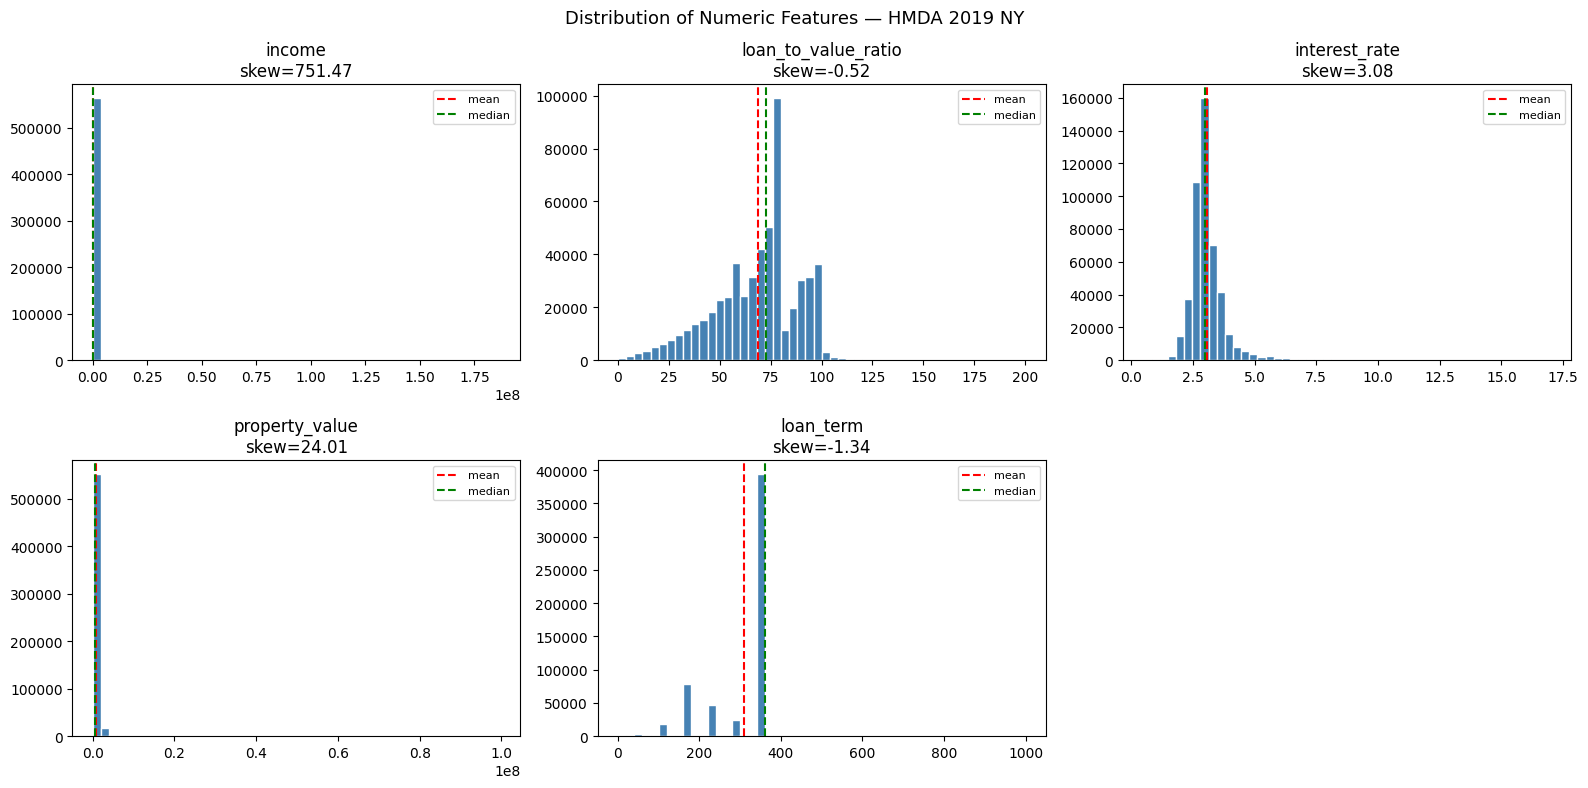

In [ ]:
from scipy import stats

print(f'{"Column":<35} {"Skewness":>10} {"Recommendation":>25}')
print(f'{"─"*75}')

impute_cols = ['income', 'loan_to_value_ratio', 'interest_rate',
               'property_value', 'loan_term']

for col in impute_cols:
    skew = df_2019[col].skew()
    if abs(skew) < 0.5:
        rec = 'Normal → mean ok'
    elif abs(skew) < 1.0:
        rec = 'Moderate skew → median'
    else:
        rec = 'High skew → median + check log'
    print(f'{col:<35} {skew:>10.4f}  {rec:>25}')

# Also plot distributions
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Distribution of Numeric Features — HMDA 2019 NY', fontsize=13)
axes = axes.flatten()

for i, col in enumerate(impute_cols):
    axes[i].hist(df_2019[col].dropna(), bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(f'{col}\nskew={df_2019[col].skew():.2f}')
    axes[i].axvline(df_2019[col].mean(),   color='red',   linestyle='--', label='mean')
    axes[i].axvline(df_2019[col].median(), color='green', linestyle='--', label='median')
    axes[i].legend(fontsize=8)

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════════════
# COST FRAMEWORK — Park raw cost metadata (before log transforms)
# interest_rate and loan_term will be transformed/dropped next
# We preserve originals here; will align to final index at end of EDA
# ══════════════════════════════════════════════════════════════════
df_cost_raw = df_2019[['loan_amount', 'interest_rate', 'loan_term', 'property_value']].copy()

# Sanity check
print(f'Cost metadata parked: {df_cost_raw.shape}')
print(df_cost_raw.describe().round(2))
print(f'\nMissing:')
print(df_cost_raw.isnull().sum())

Cost metadata parked: (600611, 4)
        loan_amount  interest_rate  loan_term  property_value
count  6.006110e+05      479964.00  579052.00       576636.00
mean   4.199638e+05           3.08     310.79       724048.81
std    2.735074e+06           0.76      80.97      1942803.44
min    5.000000e+03           0.50       1.00         5000.00
25%    1.350000e+05           2.75     240.00       255000.00
50%    2.650000e+05           2.99     360.00       475000.00
75%    4.550000e+05           3.25     360.00       735000.00
max    1.409715e+09          16.99     999.00     99605000.00

Missing:
loan_amount            0
interest_rate     120647
loan_term          21559
property_value     23975
dtype: int64


In [ ]:
import numpy as np

# ── Log transform for highly skewed columns ───────────────────────────────
# Add 1 before log to handle zeros

# Income
df_2019['income_log'] = np.log1p(df_2019['income'].clip(lower=0))
print(f'income_log skewness:         {df_2019["income_log"].skew():.4f}')

# Property value
df_2019['property_value_log'] = np.log1p(df_2019['property_value'])
print(f'property_value_log skewness: {df_2019["property_value_log"].skew():.4f}')

# ── Check if interest rate benefits from log ──────────────────────────────
interest_log_skew = np.log1p(df_2019['interest_rate'].dropna()).skew()
print(f'interest_rate_log skewness:  {interest_log_skew:.4f}  '
      f'(original: {df_2019["interest_rate"].skew():.4f})')

# ── Now impute using medians on transformed/original columns ──────────────
print(f'\nImputation plan:')
print(f'{"Column":<30} {"Transform":>15} {"Impute with":>15}')
print(f'{"─"*62}')

impute_plan = [
    ('income_log',          'log1p',  'median'),
    ('loan_to_value_ratio', 'none',   'median'),
    ('interest_rate',       'none',   'median'),
    ('property_value_log',  'log1p',  'median'),
    ('loan_term',           'none',   'median'),
]

for col, transform, method in impute_plan:
    if col in df_2019.columns:
        median_val = df_2019[col].median()
        df_2019[col] = df_2019[col].fillna(median_val)
        missing_after = df_2019[col].isnull().mean() * 100
        print(f'{col:<30} {transform:>15} {method:>15}  '
              f'skew={df_2019[col].skew():.2f}  missing={missing_after:.1f}%')

# ── Impute remaining numeric columns ─────────────────────────────────────
for col in ['loan_to_value_ratio', 'interest_rate', 'loan_term']:
    median_val = df_2019[col].median()
    df_2019[col] = df_2019[col].fillna(median_val)

print(f'\n✅ Numeric imputation complete')
print(f'Shape: {df_2019.shape[0]:,} rows × {df_2019.shape[1]} columns')

income_log skewness:         -0.5029
property_value_log skewness: 0.4279
interest_rate_log skewness:  1.2929  (original: 3.0827)

Imputation plan:
Column                               Transform     Impute with
──────────────────────────────────────────────────────────────
income_log                               log1p          median  skew=-0.51  missing=0.0%
loan_to_value_ratio                       none          median  skew=-0.58  missing=0.0%
interest_rate                             none          median  skew=3.51  missing=0.0%
property_value_log                       log1p          median  skew=0.43  missing=0.0%
loan_term                                 none          median  skew=-1.39  missing=0.0%

✅ Numeric imputation complete
Shape: 600,611 rows × 70 columns


In [ ]:
df_2019['interest_rate_log'] = np.log1p(df_2019['interest_rate'])
print(f'interest_rate_log skewness: {df_2019["interest_rate_log"].skew():.4f}')



interest_rate_log skewness: 1.4793


In [ ]:
# Loan term — convert to categorical buckets
df_2019['loan_term_cat'] = pd.cut(
    df_2019['loan_term'],
    bins=[0, 120, 180, 240, 360, 720],
    labels=['<10yr', '15yr', '20yr', '30yr', '>30yr']
)
print(df_2019['loan_term_cat'].value_counts())


loan_term_cat
30yr     445485
15yr      80802
20yr      47147
<10yr     25151
>30yr      2025
Name: count, dtype: int64


In [ ]:
# Drop original columns replaced by log versions
drop_originals = ['income', 'property_value', 'interest_rate']
df_2019 = df_2019.drop(columns=drop_originals)

print(f'Dropped originals: {drop_originals}')
print(f'Shape: {df_2019.shape[0]:,} rows × {df_2019.shape[1]} columns')

# Confirm final numeric columns
num_cols = df_2019.select_dtypes(include=[np.number]).columns.tolist()
print(f'\nFinal numeric columns ({len(num_cols)}):')
for col in num_cols:
    print(f'  {col}')



Dropped originals: ['income', 'property_value', 'interest_rate']
Shape: 600,611 rows × 69 columns

Final numeric columns (55):
  activity_year
  derived_msa-md
  county_code
  census_tract
  action_taken
  purchaser_type
  preapproval
  loan_type
  loan_purpose
  lien_status
  reverse_mortgage
  open-end_line_of_credit
  business_or_commercial_purpose
  loan_amount
  loan_to_value_ratio
  rate_spread
  hoepa_status
  loan_term
  negative_amortization
  interest_only_payment
  balloon_payment
  other_nonamortizing_features
  construction_method
  occupancy_type
  manufactured_home_secured_property_type
  manufactured_home_land_property_interest
  applicant_credit_score_type
  co-applicant_credit_score_type
  applicant_ethnicity-1
  co-applicant_ethnicity-1
  applicant_ethnicity_observed
  co-applicant_ethnicity_observed
  applicant_race-1
  co-applicant_race-1
  applicant_race_observed
  co-applicant_race_observed
  applicant_sex
  co-applicant_sex
  applicant_sex_observed
  co-applican

In [ ]:
df_2019.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600611 entries, 0 to 600610
Data columns (total 69 columns):
 #   Column                                    Non-Null Count   Dtype   
---  ------                                    --------------   -----   
 0   activity_year                             600611 non-null  int64   
 1   lei                                       600611 non-null  object  
 2   derived_msa-md                            600611 non-null  int64   
 3   state_code                                600611 non-null  object  
 4   county_code                               598321 non-null  float64 
 5   census_tract                              597765 non-null  float64 
 6   conforming_loan_limit                     594517 non-null  object  
 7   derived_loan_product_type                 600611 non-null  object  
 8   derived_dwelling_category                 600611 non-null  object  
 9   derived_ethnicity                         600611 non-null  object  
 10  derived_

In [ ]:
# DTI range to numeric midpoint conversion
def convert_dti(val):
    val = str(val).strip()
    if val == 'Exempt' or val == 'nan':
        return np.nan
    elif val == '<20%':
        return 10.0
    elif val == '20%-<30%':
        return 25.0
    elif val == '30%-<36%':
        return 33.0
    elif val == '50%-60%':
        return 55.0
    elif val == '>60%':
        return 65.0
    else:
        # Already numeric (36-49)
        try:
            return float(val)
        except:
            return np.nan

df_2019['dti'] = df_2019['debt_to_income_ratio'].apply(convert_dti)

print('DTI conversion complete')
print(f'\nMissing: {df_2019["dti"].isnull().mean()*100:.1f}%')
print(f'Skewness: {df_2019["dti"].skew():.4f}')
print(f'\nDescriptive stats:')
print(df_2019['dti'].describe())

print(f'\nDistribution by bucket:')
print(df_2019['debt_to_income_ratio'].value_counts().sort_index())

DTI conversion complete

Missing: 7.8%
Skewness: -0.0524

Descriptive stats:
count    553727.000000
mean         36.506867
std          13.016654
min          10.000000
25%          25.000000
50%          37.000000
75%          44.000000
max          65.000000
Name: dti, dtype: float64

Distribution by bucket:
debt_to_income_ratio
20%-<30%    109820
30%-<36%     93061
36           17229
37           17399
38           17754
39           18514
40           18592
41           19274
42           21045
43           18470
44           19852
45           15769
46           13862
47           14083
48           14369
49           17642
50%-60%      33184
<20%         46070
>60%         27738
Exempt       12768
Name: count, dtype: int64


In [ ]:
# Impute missing DTI with median (9.1% missing from Exempt)
dti_median = df_2019['dti'].median()
df_2019['dti'] = df_2019['dti'].fillna(dti_median)

# Drop original coded column
df_2019 = df_2019.drop(columns=['debt_to_income_ratio'])

print(f'DTI median used for imputation: {dti_median}')
print(f'Missing after imputation: {df_2019["dti"].isnull().mean()*100:.1f}%')
print(f'Shape: {df_2019.shape[0]:,} rows × {df_2019.shape[1]} columns')

DTI median used for imputation: 37.0
Missing after imputation: 0.0%
Shape: 600,611 rows × 69 columns


In [ ]:
print('Action taken distribution — HMDA 2019 NY:')
print(f'\n{"Code":<8} {"Count":>10} {"% Total":>10}  Description')
print(f'{"─"*60}')

action_names = {
    1: 'Loan originated',
    2: 'Approved not accepted',
    3: 'Application denied',
    4: 'Application withdrawn',
    5: 'File closed incomplete',
    6: 'Loan purchased',
    7: 'Preapproval denied',
    8: 'Preapproval approved not accepted'
}

for code, count in df_2019['action_taken'].value_counts().sort_index().items():
    name = action_names.get(code, 'Unknown')
    print(f'{code:<8} {count:>10,} {count/len(df_2019)*100:>9.2f}%  {name}')

Action taken distribution — HMDA 2019 NY:

Code          Count    % Total  Description
────────────────────────────────────────────────────────────
1           474,930     79.07%  Loan originated
2            19,549      3.25%  Approved not accepted
3           105,159     17.51%  Application denied
7               242      0.04%  Preapproval denied
8               731      0.12%  Preapproval approved not accepted


In [ ]:
print(df_2019['action_taken'].value_counts().sort_index())

action_taken
1    474930
2     19549
3    105159
7       242
8       731
Name: count, dtype: int64


In [ ]:
# Filter out code 8
df_2019 = df_2019[df_2019['action_taken'] != 8].copy()

# Create target variable
df_2019['loan_approved'] = df_2019['action_taken'].isin([1, 2]).astype(int)

print(f'Shape after removing code 8: {df_2019.shape[0]:,} rows × {df_2019.shape[1]} columns')
print(f'\nTarget variable distribution:')
print(f'  Approved (1): {df_2019["loan_approved"].sum():,} ({df_2019["loan_approved"].mean()*100:.1f}%)')
print(f'  Denied   (0): {(df_2019["loan_approved"]==0).sum():,} ({(1-df_2019["loan_approved"].mean())*100:.1f}%)')

# Compare with 2017
print(f'\n  2017 approval rate: 80.0%')
print(f'  2019 approval rate: {df_2019["loan_approved"].mean()*100:.1f}%')

Shape after removing code 8: 599,880 rows × 70 columns

Target variable distribution:
  Approved (1): 494,479 (82.4%)
  Denied   (0): 105,401 (17.6%)

  2017 approval rate: 80.0%
  2019 approval rate: 82.4%


In [ ]:
# Verify target matches action_taken
print(pd.crosstab(df_2019['action_taken'], df_2019['loan_approved']))

loan_approved       0       1
action_taken                 
1                   0  474930
2                   0   19549
3              105159       0
7                 242       0


In [ ]:
df_2019 = df_2019.drop(columns=['action_taken'])
print(f'action_taken dropped ✅')
print(f'Shape: {df_2019.shape[0]:,} rows × {df_2019.shape[1]} columns')

action_taken dropped ✅
Shape: 599,880 rows × 69 columns


In [ ]:
import numpy as np

num_cols = df_2019.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != 'loan_approved']

correlations = {}
for col in num_cols:
    corr = df_2019[col].corr(df_2019['loan_approved'])
    correlations[col] = corr

corr_df = pd.DataFrame.from_dict(correlations, orient='index',
                                  columns=['correlation'])\
            .sort_values('correlation', key=abs, ascending=False)

print(f'Correlation with loan_approved (sorted by absolute value):')
print(f'\n{"Column":<45} {"Correlation":>12} {"Strength":>12}')
print(f'{"─"*72}')

for col, row in corr_df.iterrows():
    r = row['correlation']
    if abs(r) > 0.10:
        strength = 'Strong ✅'
    elif abs(r) > 0.05:
        strength = 'Moderate'
    else:
        strength = 'Weak ❌'
    print(f'{col:<45} {r:>12.4f} {strength:>12}')

Correlation with loan_approved (sorted by absolute value):

Column                                         Correlation     Strength
────────────────────────────────────────────────────────────────────────
higher_priced_loan                                  0.8131     Strong ✅
hoepa_status                                       -0.7180     Strong ✅
dti                                                -0.2811     Strong ✅
rate_spread                                         0.2077     Strong ✅
lien_status                                        -0.2063     Strong ✅
income_log                                          0.1685     Strong ✅
purchaser_type                                      0.1419     Strong ✅
co-applicant_ethnicity-1                           -0.0792     Moderate
co-applicant_sex                                   -0.0784     Moderate
tract_minority_population_percent                  -0.0777     Moderate
co-applicant_sex_observed                          -0.0735     Moderate
co-

In [ ]:
drop_leakage = [
    'higher_priced_loan',      # derived from rate_spread post-decision
    'hoepa_status',            # assigned post-origination
    'denial_reason-1',         # recorded after denial
    'purchaser_type',          # post-origination
    'rate_spread',             # only reported for originated loans
]

df_2019 = df_2019.drop(columns=drop_leakage)
print(f'Leakage columns dropped: {len(drop_leakage)}')
print(f'Shape: {df_2019.shape[0]:,} rows × {df_2019.shape[1]} columns')

Leakage columns dropped: 5
Shape: 599,880 rows × 64 columns


In [ ]:
import numpy as np

num_cols = df_2019.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != 'loan_approved']

correlations = {}
for col in num_cols:
    corr = df_2019[col].corr(df_2019['loan_approved'])
    correlations[col] = corr

corr_df = pd.DataFrame.from_dict(correlations, orient='index',
                                  columns=['correlation'])\
            .sort_values('correlation', key=abs, ascending=False)

print(f'Correlation with loan_approved (sorted by absolute value):')
print(f'\n{"Column":<45} {"Correlation":>12} {"Strength":>12}')
print(f'{"─"*72}')

for col, row in corr_df.iterrows():
    r = row['correlation']
    if abs(r) > 0.10:
        strength = 'Strong ✅'
    elif abs(r) > 0.05:
        strength = 'Moderate'
    else:
        strength = 'Weak ❌'
    print(f'{col:<45} {r:>12.4f} {strength:>12}')

Correlation with loan_approved (sorted by absolute value):

Column                                         Correlation     Strength
────────────────────────────────────────────────────────────────────────
dti                                                -0.2811     Strong ✅
lien_status                                        -0.2063     Strong ✅
income_log                                          0.1685     Strong ✅
co-applicant_ethnicity-1                           -0.0792     Moderate
co-applicant_sex                                   -0.0784     Moderate
tract_minority_population_percent                  -0.0777     Moderate
co-applicant_sex_observed                          -0.0735     Moderate
co-applicant_ethnicity_observed                    -0.0734     Moderate
co-applicant_race_observed                         -0.0733     Moderate
tract_to_msa_income_percentage                      0.0716     Moderate
construction_method                                -0.0709     Moderate
co-

In [ ]:
# Drop zero variance and leakage columns
drop_cols = [
    'activity_year',        # single value 2019
    'state_code',           # single value NY
    'lei',                  # institution ID — not a feature
    'census_tract',         # too granular, county_code covers geography
    'derived_msa-md',       # redundant with county_code
    'ffiec_msa_md_median_family_income',  # r=0.007 — no signal
    'tract_median_age_of_housing_units',  # r=-0.015 — no signal
    'tract_population',     # r=0.038 — weak, covered by other tract vars
    'tract_one_to_four_family_homes',     # r=0.037 — weak
]

# Only drop if present
drop_cols = [c for c in drop_cols if c in df_2019.columns]
df_2019 = df_2019.drop(columns=drop_cols)

print(f'Dropped {len(drop_cols)} low-signal columns')
print(f'Shape: {df_2019.shape[0]:,} rows × {df_2019.shape[1]} columns')
print(f'\nRemaining columns:')
for col in df_2019.columns:
    print(f'  {col}')

Dropped 9 low-signal columns
Shape: 599,880 rows × 55 columns

Remaining columns:
  county_code
  conforming_loan_limit
  derived_loan_product_type
  derived_dwelling_category
  derived_ethnicity
  derived_race
  derived_sex
  preapproval
  loan_type
  loan_purpose
  lien_status
  reverse_mortgage
  open-end_line_of_credit
  business_or_commercial_purpose
  loan_amount
  loan_to_value_ratio
  loan_term
  negative_amortization
  interest_only_payment
  balloon_payment
  other_nonamortizing_features
  construction_method
  occupancy_type
  manufactured_home_secured_property_type
  manufactured_home_land_property_interest
  total_units
  applicant_credit_score_type
  co-applicant_credit_score_type
  applicant_ethnicity-1
  co-applicant_ethnicity-1
  applicant_ethnicity_observed
  co-applicant_ethnicity_observed
  applicant_race-1
  co-applicant_race-1
  applicant_race_observed
  co-applicant_race_observed
  applicant_sex
  co-applicant_sex
  applicant_sex_observed
  co-applicant_sex_obser

In [ ]:
import numpy as np

num_cols = df_2019.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != 'loan_approved']

correlations = {}
for col in num_cols:
    corr = df_2019[col].corr(df_2019['loan_approved'])
    correlations[col] = corr

corr_df = pd.DataFrame.from_dict(correlations, orient='index',
                                  columns=['correlation'])\
            .sort_values('correlation', key=abs, ascending=False)

print(f'Correlation with loan_approved (sorted by absolute value):')
print(f'\n{"Column":<45} {"Correlation":>12} {"Strength":>12}')
print(f'{"─"*72}')

for col, row in corr_df.iterrows():
    r = row['correlation']
    if abs(r) > 0.10:
        strength = 'Strong ✅'
    elif abs(r) > 0.05:
        strength = 'Moderate'
    else:
        strength = 'Weak ❌'
    print(f'{col:<45} {r:>12.4f} {strength:>12}')

Correlation with loan_approved (sorted by absolute value):

Column                                         Correlation     Strength
────────────────────────────────────────────────────────────────────────
dti                                                -0.2811     Strong ✅
lien_status                                        -0.2063     Strong ✅
income_log                                          0.1685     Strong ✅
co-applicant_ethnicity-1                           -0.0792     Moderate
co-applicant_sex                                   -0.0784     Moderate
tract_minority_population_percent                  -0.0777     Moderate
co-applicant_sex_observed                          -0.0735     Moderate
co-applicant_ethnicity_observed                    -0.0734     Moderate
co-applicant_race_observed                         -0.0733     Moderate
tract_to_msa_income_percentage                      0.0716     Moderate
construction_method                                -0.0709     Moderate
co-

In [ ]:
print(f'Shape: {df_2019.shape[0]:,} rows × {df_2019.shape[1]} columns')
print(f'\nColumns remaining:')
for col in df_2019.columns:
    print(f'  {col}')

Shape: 599,880 rows × 55 columns

Columns remaining:
  county_code
  conforming_loan_limit
  derived_loan_product_type
  derived_dwelling_category
  derived_ethnicity
  derived_race
  derived_sex
  preapproval
  loan_type
  loan_purpose
  lien_status
  reverse_mortgage
  open-end_line_of_credit
  business_or_commercial_purpose
  loan_amount
  loan_to_value_ratio
  loan_term
  negative_amortization
  interest_only_payment
  balloon_payment
  other_nonamortizing_features
  construction_method
  occupancy_type
  manufactured_home_secured_property_type
  manufactured_home_land_property_interest
  total_units
  applicant_credit_score_type
  co-applicant_credit_score_type
  applicant_ethnicity-1
  co-applicant_ethnicity-1
  applicant_ethnicity_observed
  co-applicant_ethnicity_observed
  applicant_race-1
  co-applicant_race-1
  applicant_race_observed
  co-applicant_race_observed
  applicant_sex
  co-applicant_sex
  applicant_sex_observed
  co-applicant_sex_observed
  applicant_age
  co-appl

In [ ]:
drop_admin = [
    'submission_of_application',
    'initially_payable_to_institution',
    'aus-1',
    'total_units',
    'applicant_age_above_62',
    'derived_loan_product_type',
    'derived_dwelling_category',
    'loan_term',
]

drop_admin = [c for c in drop_admin if c in df_2019.columns]
df_2019 = df_2019.drop(columns=drop_admin)

print(f'Dropped {len(drop_admin)} administrative columns')
print(f'Shape: {df_2019.shape[0]:,} rows × {df_2019.shape[1]} columns')

Dropped 8 administrative columns
Shape: 599,880 rows × 47 columns


In [ ]:
near_constant = [
    'negative_amortization', 'interest_only_payment', 'balloon_payment',
    'other_nonamortizing_features', 'reverse_mortgage',
    'open-end_line_of_credit', 'business_or_commercial_purpose',
    'manufactured_home_secured_property_type',
    'manufactured_home_land_property_interest'
]

print(f'{"Column":<45} {"Top Value %":>12}')
print(f'{"─"*60}')
for col in near_constant:
    if col in df_2019.columns:
        top_pct = df_2019[col].value_counts(normalize=True).iloc[0] * 100
        flag = ' ❌ drop' if top_pct > 95 else ' ✅ keep'
        print(f'{col:<45} {top_pct:>11.1f}%{flag}')

Column                                         Top Value %
────────────────────────────────────────────────────────────
negative_amortization                                97.9% ❌ drop
interest_only_payment                                88.4% ✅ keep
balloon_payment                                      96.8% ❌ drop
other_nonamortizing_features                         97.8% ❌ drop
reverse_mortgage                                     97.6% ❌ drop
open-end_line_of_credit                              85.2% ✅ keep
business_or_commercial_purpose                       93.7% ✅ keep
manufactured_home_secured_property_type              96.8% ❌ drop
manufactured_home_land_property_interest             96.8% ❌ drop


In [ ]:
drop_near_constant = [
    'negative_amortization',
    'balloon_payment',
    'reverse_mortgage',
    'manufactured_home_secured_property_type',
    'manufactured_home_land_property_interest',
]

df_2019 = df_2019.drop(columns=drop_near_constant)

print(f'Dropped {len(drop_near_constant)} near-constant columns')
print(f'Shape: {df_2019.shape[0]:,} rows × {df_2019.shape[1]} columns')
print(f'\nRemaining columns:')
for col in df_2019.columns:
    print(f'  {col}')

Dropped 5 near-constant columns
Shape: 599,880 rows × 42 columns

Remaining columns:
  county_code
  conforming_loan_limit
  derived_ethnicity
  derived_race
  derived_sex
  preapproval
  loan_type
  loan_purpose
  lien_status
  open-end_line_of_credit
  business_or_commercial_purpose
  loan_amount
  loan_to_value_ratio
  interest_only_payment
  other_nonamortizing_features
  construction_method
  occupancy_type
  applicant_credit_score_type
  co-applicant_credit_score_type
  applicant_ethnicity-1
  co-applicant_ethnicity-1
  applicant_ethnicity_observed
  co-applicant_ethnicity_observed
  applicant_race-1
  co-applicant_race-1
  applicant_race_observed
  co-applicant_race_observed
  applicant_sex
  co-applicant_sex
  applicant_sex_observed
  co-applicant_sex_observed
  applicant_age
  co-applicant_age
  tract_minority_population_percent
  tract_to_msa_income_percentage
  tract_owner_occupied_units
  income_log
  property_value_log
  interest_rate_log
  loan_term_cat
  dti
  loan_appro

In [ ]:
for col in ['derived_race', 'derived_ethnicity', 'derived_sex',
            'applicant_sex', 'co-applicant_sex']:
    if col in df_2019.columns:
        print(f'\n{col}:')
        print(df_2019[col].value_counts())


derived_race:
derived_race
White                                        380298
Race Not Available                           110336
Asian                                         55110
Black or African American                     40095
Joint                                         10117
American Indian or Alaska Native               1797
Native Hawaiian or Other Pacific Islander      1103
2 or more minority races                        892
Free Form Text Only                             132
Name: count, dtype: int64

derived_ethnicity:
derived_ethnicity
Not Hispanic or Latino     442755
Ethnicity Not Available    103531
Hispanic or Latino          41953
Joint                       11294
Free Form Text Only           347
Name: count, dtype: int64

derived_sex:
derived_sex
Joint                207796
Male                 195732
Female               134833
Sex Not Available     61519
Name: count, dtype: int64

applicant_sex:
applicant_sex
1    341159
2    196881
3     50103
4     11416
6 

In [ ]:
print(df_2019['applicant_race-1'].value_counts())
print()

applicant_race-1
5.0     386023
6.0      98868
2.0      48989
3.0      41726
7.0      11468
21.0      3421
22.0      2932
1.0       2657
27.0      1178
4.0        730
25.0       624
23.0       464
44.0       418
24.0       116
26.0       109
42.0        13
41.0         9
43.0         3
Name: count, dtype: int64



In [ ]:
# Drop applicant_race-1 and co-applicant_race-1
drop_race_coded = ['applicant_race-1', 'co-applicant_race-1']
drop_race_coded = [c for c in drop_race_coded if c in df_2019.columns]
df_2019 = df_2019.drop(columns=drop_race_coded)
print(f'Dropped coded race columns: {drop_race_coded}')

# Drop rows where derived_race is not available
before = len(df_2019)
df_2019 = df_2019[df_2019['derived_race'] != 'Race Not Available'].copy()
df_2019 = df_2019[df_2019['derived_race'] != 'Free Form Text Only'].copy()
after = len(df_2019)

print(f'\nRows dropped (race not available + free form): {before - after:,}')
print(f'Shape: {df_2019.shape[0]:,} rows × {df_2019.shape[1]} columns')

print(f'\nRemaining race groups:')
print(df_2019['derived_race'].value_counts())

Dropped coded race columns: ['applicant_race-1', 'co-applicant_race-1']

Rows dropped (race not available + free form): 110,468
Shape: 489,412 rows × 40 columns

Remaining race groups:
derived_race
White                                        380298
Asian                                         55110
Black or African American                     40095
Joint                                         10117
American Indian or Alaska Native               1797
Native Hawaiian or Other Pacific Islander      1103
2 or more minority races                        892
Name: count, dtype: int64


In [ ]:
# Drop Joint rows
before = len(df_2019)
df_2019 = df_2019[df_2019['derived_race'] != 'Joint'].copy()
after = len(df_2019)

print(f'Rows dropped (Joint): {before - after:,}')
print(f'Shape: {df_2019.shape[0]:,} rows × {df_2019.shape[1]} columns')

print(f'\nFinal race groups:')
print(df_2019['derived_race'].value_counts())

Rows dropped (Joint): 10,117
Shape: 479,295 rows × 40 columns

Final race groups:
derived_race
White                                        380298
Asian                                         55110
Black or African American                     40095
American Indian or Alaska Native               1797
Native Hawaiian or Other Pacific Islander      1103
2 or more minority races                        892
Name: count, dtype: int64


In [ ]:
# race_group — keep detailed groups
df_2019['race_group'] = df_2019['derived_race']

# race_binary — 1=White, 0=NonWhite
df_2019['race_binary'] = (df_2019['derived_race'] == 'White').astype(int)

print('race_binary distribution:')
print(df_2019['race_binary'].value_counts())
print(f'\nWhite:    {(df_2019["race_binary"]==1).sum():,} ({(df_2019["race_binary"]==1).mean()*100:.1f}%)')
print(f'NonWhite: {(df_2019["race_binary"]==0).sum():,} ({(df_2019["race_binary"]==0).mean()*100:.1f}%)')

# Quick approval rate check by race
print(f'\nApproval rate by race:')
print(df_2019.groupby('derived_race')['loan_approved'].agg(['mean','count'])\
      .rename(columns={'mean':'approval_rate','count':'n'})\
      .sort_values('n', ascending=False)\
      .assign(approval_rate=lambda x: x['approval_rate']*100)\
      .round(2))

race_binary distribution:
race_binary
1    380298
0     98997
Name: count, dtype: int64

White:    380,298 (79.3%)
NonWhite: 98,997 (20.7%)

Approval rate by race:
                                           approval_rate       n
derived_race                                                    
White                                              84.20  380298
Asian                                              83.85   55110
Black or African American                          72.82   40095
American Indian or Alaska Native                   63.61    1797
Native Hawaiian or Other Pacific Islander          65.46    1103
2 or more minority races                           60.99     892


In [ ]:
# ECOA 80% rule check
white_appr = df_2019[df_2019['race_binary']==1]['loan_approved'].mean()
nw_appr    = df_2019[df_2019['race_binary']==0]['loan_approved'].mean()
di         = nw_appr / white_appr

print(f'White approval rate:    {white_appr*100:.1f}%')
print(f'NonWhite approval rate: {nw_appr*100:.1f}%')
print(f'Disparate Impact (DI):  {di:.4f}  {"✅ above 0.80" if di >= 0.80 else "⚠️ BELOW 0.80 ECOA threshold"}')
print(f'Racial gap:             {(white_appr - nw_appr)*100:.1f}pp')

# Compare with 2017
print(f'\n2017 DI: 0.8913')
print(f'2019 DI: {di:.4f}')

White approval rate:    84.2%
NonWhite approval rate: 78.6%
Disparate Impact (DI):  0.9336  ✅ above 0.80
Racial gap:             5.6pp

2017 DI: 0.8913
2019 DI: 0.9336


In [ ]:
print('Ethnicity distribution:')
print(df_2019['derived_ethnicity'].value_counts())

print(f'\nApproval rate by ethnicity:')
print(df_2019.groupby('derived_ethnicity')['loan_approved'].agg(['mean','count'])\
      .rename(columns={'mean':'approval_rate','count':'n'})\
      .sort_values('n', ascending=False)\
      .assign(approval_rate=lambda x: x['approval_rate']*100)\
      .round(2))

Ethnicity distribution:
derived_ethnicity
Not Hispanic or Latino     425005
Hispanic or Latino          33224
Ethnicity Not Available     11685
Joint                        9088
Free Form Text Only           293
Name: count, dtype: int64

Approval rate by ethnicity:
                         approval_rate       n
derived_ethnicity                             
Not Hispanic or Latino           83.74  425005
Hispanic or Latino               76.86   33224
Ethnicity Not Available          75.99   11685
Joint                            83.20    9088
Free Form Text Only              56.31     293


In [ ]:
# No drops for ethnicity — keep all groups including Joint and Free Form Text
# derived_race is the primary sensitive attribute
# derived_ethnicity kept as a feature with all categories

print('Ethnicity — keeping all groups as feature ✅')
print(f'Shape: {df_2019.shape[0]:,} rows × {df_2019.shape[1]} columns')

# Quick check — derived_race is clean, derived_ethnicity is a feature
print(f'\nderived_race unique values:    {df_2019["derived_race"].nunique()}')
print(f'derived_ethnicity unique values: {df_2019["derived_ethnicity"].nunique()}')

Ethnicity — keeping all groups as feature ✅
Shape: 479,295 rows × 42 columns

derived_race unique values:    6
derived_ethnicity unique values: 5


In [ ]:
# Check if ethnicity needs any cleaning first
print('Current derived_ethnicity values:')
print(df_2019['derived_ethnicity'].value_counts())

# Create ethnicity_binary — 1=Not Hispanic, 0=Hispanic
df_2019['ethnicity_binary'] = (df_2019['derived_ethnicity'] == 'Not Hispanic or Latino').astype(int)

print(f'\nethnicity_binary distribution:')
print(f'Not Hispanic (1): {(df_2019["ethnicity_binary"]==1).sum():,} ({(df_2019["ethnicity_binary"]==1).mean()*100:.1f}%)')
print(f'Hispanic     (0): {(df_2019["ethnicity_binary"]==0).sum():,} ({(df_2019["ethnicity_binary"]==0).mean()*100:.1f}%)')

# Approval rate by ethnicity binary
white_eth  = df_2019[df_2019['ethnicity_binary']==1]['loan_approved'].mean()
hisp_eth   = df_2019[df_2019['ethnicity_binary']==0]['loan_approved'].mean()
di_eth     = hisp_eth / white_eth

print(f'\nApproval rate — Not Hispanic: {white_eth*100:.1f}%')
print(f'Approval rate — Hispanic:     {hisp_eth*100:.1f}%')
print(f'Disparate Impact:             {di_eth:.4f}  {"✅" if di_eth >= 0.80 else "⚠️ BELOW 0.80"}')
print(f'Gap:                          {(white_eth - hisp_eth)*100:.1f}pp')

Current derived_ethnicity values:
derived_ethnicity
Not Hispanic or Latino     425005
Hispanic or Latino          33224
Ethnicity Not Available     11685
Joint                        9088
Free Form Text Only           293
Name: count, dtype: int64

ethnicity_binary distribution:
Not Hispanic (1): 425,005 (88.7%)
Hispanic     (0): 54,290 (11.3%)

Approval rate — Not Hispanic: 83.7%
Approval rate — Hispanic:     77.6%
Disparate Impact:             0.9270  ✅
Gap:                          6.1pp


In [ ]:
# Create ethnicity with three categories
def encode_ethnicity(val):
    if val == 'Not Hispanic or Latino':
        return 1
    elif val == 'Hispanic or Latino':
        return 0
    else:
        return 2  # Unknown/Joint/Free Form

df_2019['ethnicity_binary'] = df_2019['derived_ethnicity'].apply(encode_ethnicity)

print('ethnicity_binary distribution:')
print(f'Not Hispanic (1): {(df_2019["ethnicity_binary"]==1).sum():,}')
print(f'Hispanic     (0): {(df_2019["ethnicity_binary"]==0).sum():,}')
print(f'Unknown      (2): {(df_2019["ethnicity_binary"]==2).sum():,}')

# Approval rate — known groups only
known = df_2019[df_2019['ethnicity_binary'].isin([0,1])]
nh   = known[known['ethnicity_binary']==1]['loan_approved'].mean()
h    = known[known['ethnicity_binary']==0]['loan_approved'].mean()
di   = h / nh

print(f'\nAmong known ethnicity only:')
print(f'Not Hispanic: {nh*100:.1f}%')
print(f'Hispanic:     {h*100:.1f}%')
print(f'DI:           {di:.4f}  {"✅" if di>=0.80 else "⚠️ BELOW 0.80"}')
print(f'Gap:          {(nh-h)*100:.1f}pp')

ethnicity_binary distribution:
Not Hispanic (1): 425,005
Hispanic     (0): 33,224
Unknown      (2): 21,066

Among known ethnicity only:
Not Hispanic: 83.7%
Hispanic:     76.9%
DI:           0.9179  ✅
Gap:          6.9pp


In [ ]:
print('applicant_sex:')
print(df_2019['applicant_sex'].value_counts())

print('\nco-applicant_sex:')
print(df_2019['co-applicant_sex'].value_counts())

applicant_sex:
applicant_sex
1    302413
2    175121
3      1481
6       274
4         6
Name: count, dtype: int64

co-applicant_sex:
co-applicant_sex
5    278464
2    134383
1     62146
3      3836
6       296
4       170
Name: count, dtype: int64


In [ ]:
print('derived_sex:')
print(df_2019['derived_sex'].value_counts())

derived_sex:
derived_sex
Joint                180300
Male                 175700
Female               121808
Sex Not Available      1487
Name: count, dtype: int64


In [ ]:
# Drop raw sex columns — use derived_sex only
drop_sex = ['applicant_sex', 'co-applicant_sex']
df_2019 = df_2019.drop(columns=drop_sex)

# Also drop the label columns we created temporarily
drop_temp = ['applicant_sex_label', 'co_applicant_sex_label']
drop_temp = [c for c in drop_temp if c in df_2019.columns]
df_2019 = df_2019.drop(columns=drop_temp)

print(f'Dropped: {drop_sex + drop_temp}')
print(f'Shape: {df_2019.shape[0]:,} rows × {df_2019.shape[1]} columns')

print(f'\nderived_sex value counts:')
print(df_2019['derived_sex'].value_counts())

print(f'\nApproval rate by derived_sex:')
print(df_2019.groupby('derived_sex')['loan_approved'].agg(['mean','count'])\
      .rename(columns={'mean':'approval_rate','count':'n'})\
      .assign(approval_rate=lambda x: x['approval_rate']*100)\
      .sort_values('n', ascending=False)\
      .round(2))

Dropped: ['applicant_sex', 'co-applicant_sex']
Shape: 479,295 rows × 41 columns

derived_sex value counts:
derived_sex
Joint                180300
Male                 175700
Female               121808
Sex Not Available      1487
Name: count, dtype: int64

Approval rate by derived_sex:
                   approval_rate       n
derived_sex                             
Joint                      86.98  180300
Male                       80.69  175700
Female                     80.70  121808
Sex Not Available          75.32    1487


In [ ]:
# Create sex_binary — keep simple
# 1 = Male, 2 = Female, 3 = Joint, 4 = Not Available
# No need for binary since no discrimination signal
# Keep as categorical feature for modeling

sex_map = {
    'Male':              1,
    'Female':            2,
    'Joint':             3,
    'Sex Not Available': 4
}

df_2019['sex_code'] = df_2019['derived_sex'].map(sex_map)

print('sex_code distribution:')
print(df_2019['sex_code'].value_counts().sort_index())

# Drop derived_sex string — keep sex_code
df_2019 = df_2019.drop(columns=['derived_sex'])
print(f'\nShape: {df_2019.shape[0]:,} rows × {df_2019.shape[1]} columns')


sex_code distribution:
sex_code
1    175700
2    121808
3    180300
4      1487
Name: count, dtype: int64

Shape: 479,295 rows × 41 columns


In [ ]:
# Check all remaining non-numeric columns
cat_cols = df_2019.select_dtypes(include=['object']).columns.tolist()

print(f'Remaining categorical columns: {len(cat_cols)}')
print(f'{"─"*70}')

for col in cat_cols:
    print(f'\n{col}:')
    print(df_2019[col].value_counts())

Remaining categorical columns: 6
──────────────────────────────────────────────────────────────────────

conforming_loan_limit:
conforming_loan_limit
C     455358
NC     23731
U         19
Name: count, dtype: int64

derived_ethnicity:
derived_ethnicity
Not Hispanic or Latino     425005
Hispanic or Latino          33224
Ethnicity Not Available     11685
Joint                        9088
Free Form Text Only           293
Name: count, dtype: int64

derived_race:
derived_race
White                                        380298
Asian                                         55110
Black or African American                     40095
American Indian or Alaska Native               1797
Native Hawaiian or Other Pacific Islander      1103
2 or more minority races                        892
Name: count, dtype: int64

applicant_age:
applicant_age
35-44    128573
45-54    112978
25-34     89975
55-64     84316
65-74     41977
>74       12691
<25        8699
8888         86
Name: count, dtype: int64



In [ ]:
df_2019.info()

<class 'pandas.core.frame.DataFrame'>
Index: 479295 entries, 7 to 600610
Data columns (total 41 columns):
 #   Column                             Non-Null Count   Dtype   
---  ------                             --------------   -----   
 0   county_code                        477937 non-null  float64 
 1   conforming_loan_limit              479108 non-null  object  
 2   derived_ethnicity                  479295 non-null  object  
 3   derived_race                       479295 non-null  object  
 4   preapproval                        479295 non-null  int64   
 5   loan_type                          479295 non-null  int64   
 6   loan_purpose                       479295 non-null  int64   
 7   lien_status                        479295 non-null  int64   
 8   open-end_line_of_credit            479295 non-null  int64   
 9   business_or_commercial_purpose     479295 non-null  int64   
 10  loan_amount                        479295 non-null  float64 
 11  loan_to_value_ratio            

In [ ]:
# Full column list with dtypes and unique values
print(f'Shape: {df_2019.shape[0]:,} rows × {df_2019.shape[1]} columns')
print(f'\n{"#":<4} {"Column":<45} {"Dtype":>10} {"Unique":>8} {"Missing%":>10}')
print(f'{"─"*80}')

for i, col in enumerate(df_2019.columns):
    dtype   = df_2019[col].dtype
    unique  = df_2019[col].nunique()
    missing = df_2019[col].isnull().mean() * 100
    print(f'{i+1:<4} {col:<45} {str(dtype):>10} {unique:>8} {missing:>9.1f}%')

Shape: 479,295 rows × 41 columns

#    Column                                             Dtype   Unique   Missing%
────────────────────────────────────────────────────────────────────────────────
1    county_code                                      float64       62       0.3%
2    conforming_loan_limit                             object        3       0.0%
3    derived_ethnicity                                 object        5       0.0%
4    derived_race                                      object        6       0.0%
5    preapproval                                        int64        2       0.0%
6    loan_type                                          int64        4       0.0%
7    loan_purpose                                       int64        6       0.0%
8    lien_status                                        int64        2       0.0%
9    open-end_line_of_credit                            int64        3       0.0%
10   business_or_commercial_purpose                     int64    

In [ ]:
drop_redundant = [
    'applicant_ethnicity-1', 'co-applicant_ethnicity-1',
    'applicant_ethnicity_observed', 'co-applicant_ethnicity_observed',
    'applicant_race_observed', 'co-applicant_race_observed',
    'applicant_sex_observed', 'co-applicant_sex_observed',
    'derived_race', 'derived_ethnicity'
]

drop_redundant = [c for c in drop_redundant if c in df_2019.columns]
df_2019 = df_2019.drop(columns=drop_redundant)

print(f'Dropped {len(drop_redundant)} redundant columns')
print(f'Shape: {df_2019.shape[0]:,} rows × {df_2019.shape[1]} columns')
print(f'\nFinal columns:')
for i, col in enumerate(df_2019.columns):
    print(f'  {i+1:<3} {col}')

Dropped 10 redundant columns
Shape: 479,295 rows × 31 columns

Final columns:
  1   county_code
  2   conforming_loan_limit
  3   preapproval
  4   loan_type
  5   loan_purpose
  6   lien_status
  7   open-end_line_of_credit
  8   business_or_commercial_purpose
  9   loan_amount
  10  loan_to_value_ratio
  11  interest_only_payment
  12  other_nonamortizing_features
  13  construction_method
  14  occupancy_type
  15  applicant_credit_score_type
  16  co-applicant_credit_score_type
  17  applicant_age
  18  co-applicant_age
  19  tract_minority_population_percent
  20  tract_to_msa_income_percentage
  21  tract_owner_occupied_units
  22  income_log
  23  property_value_log
  24  interest_rate_log
  25  loan_term_cat
  26  dti
  27  loan_approved
  28  race_group
  29  race_binary
  30  ethnicity_binary
  31  sex_code


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import pandas as pd
import numpy as np

# ── Step 1: Correlation with target ───────────────────────────────────────
num_cols = df_2019.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ['loan_approved', 'race_binary',
                                              'ethnicity_binary', 'race_group']]

print('CORRELATION WITH loan_approved:')
print(f'\n{"Column":<45} {"Correlation":>12} {"Strength":>12}')
print(f'{"─"*72}')

corr_dict = {}
for col in num_cols:
    r = df_2019[col].corr(df_2019['loan_approved'])
    corr_dict[col] = r
    strength = 'Strong ✅' if abs(r)>0.10 else 'Moderate' if abs(r)>0.05 else 'Weak ❌'
    print(f'{col:<45} {r:>12.4f} {strength:>12}')

# ── Step 2: VIF ───────────────────────────────────────────────────────────
print(f'\n{"─"*72}')
print('VIF ANALYSIS:')
print(f'\n{"Column":<45} {"VIF":>10} {"Decision":>15}')
print(f'{"─"*72}')

# Use only numeric columns with no missing
vif_cols = [c for c in num_cols if df_2019[c].isnull().sum() == 0]
X_vif = df_2019[vif_cols].copy()
X_vif = add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data['column'] = X_vif.columns
vif_data['VIF']    = [variance_inflation_factor(X_vif.values, i)
                      for i in range(X_vif.shape[1])]
vif_data = vif_data[vif_data['column'] != 'const']\
           .sort_values('VIF', ascending=False)

for _, row in vif_data.iterrows():
    vif = row['VIF']
    decision = 'DROP ❌' if vif > 10 else 'REVIEW ⚠️' if vif > 5 else 'KEEP ✅'
    print(f'{row["column"]:<45} {vif:>10.2f} {decision:>15}')

CORRELATION WITH loan_approved:

Column                                         Correlation     Strength
────────────────────────────────────────────────────────────────────────
county_code                                         0.0112       Weak ❌
preapproval                                        -0.0542     Moderate
loan_type                                           0.0013       Weak ❌
loan_purpose                                        0.0259       Weak ❌
lien_status                                        -0.2033     Strong ✅
open-end_line_of_credit                             0.0132       Weak ❌
business_or_commercial_purpose                      0.0127       Weak ❌
loan_amount                                         0.0105       Weak ❌
loan_to_value_ratio                                 0.0160       Weak ❌
interest_only_payment                               0.0129       Weak ❌
other_nonamortizing_features                        0.0127       Weak ❌
construction_method           

In [ ]:
# Recover applicant_credit_score_type from raw data
# Filter to same rows as df_2019
df_2019['applicant_credit_score_type'] = df_raw_2019.loc[
    df_2019.index, 'applicant_credit_score_type'
]

print('Recovered applicant_credit_score_type ✅')
print(df_2019['applicant_credit_score_type'].value_counts())
print(f'Missing: {df_2019["applicant_credit_score_type"].isnull().mean()*100:.1f}%')

Recovered applicant_credit_score_type ✅
applicant_credit_score_type
1       127548
2       115881
3       114425
9        48307
8        39274
7        19358
1111      9689
6         4350
4          340
5          123
Name: count, dtype: int64
Missing: 0.0%


In [ ]:
# Approval rate by credit score type
print(df_2019.groupby('applicant_credit_score_type')['loan_approved']\
      .agg(['mean','count'])\
      .rename(columns={'mean':'approval_rate','count':'n'})\
      .assign(approval_rate=lambda x: x['approval_rate']*100)\
      .sort_values('approval_rate', ascending=False)\
      .round(2))

                             approval_rate       n
applicant_credit_score_type                       
5                                    91.87     123
1                                    88.34  127548
4                                    88.24     340
3                                    87.80  114425
1111                                 86.36    9689
2                                    85.39  115881
9                                    76.94   48307
7                                    72.49   19358
6                                    71.70    4350
8                                    58.13   39274


In [ ]:
# Do NonWhite applicants get evaluated by lower-approval score types more often?
print(df_2019.groupby(['race_binary', 'applicant_credit_score_type'])\
      .size().unstack(fill_value=0)\
      .apply(lambda x: x/x.sum()*100, axis=1)\
      .round(1))

applicant_credit_score_type  1     2     3     4     5     6     7     8     \
race_binary                                                                   
0                            27.2  24.1  24.4   0.1   0.0   0.7   5.0   6.4   
1                            26.5  24.2  23.7   0.1   0.0   1.0   3.8   8.7   

applicant_credit_score_type  9     1111  
race_binary                              
0                            10.7   1.4  
1                             9.9   2.2  


In [ ]:
print('applicant_age:')
print(df_2019['applicant_age'].value_counts().sort_index())

print('\nco-applicant_age:')
print(df_2019['co-applicant_age'].value_counts().sort_index())

applicant_age:
applicant_age
25-34     89975
35-44    128573
45-54    112978
55-64     84316
65-74     41977
8888         86
<25        8699
>74       12691
Name: count, dtype: int64

co-applicant_age:
co-applicant_age
25-34     38173
35-44     53445
45-54     44916
55-64     35522
65-74     19603
8888        332
9999     278384
<25        3647
>74        5273
Name: count, dtype: int64


In [ ]:
# Age midpoints
age_map = {
    '<25':  22,
    '25-34': 29,
    '35-44': 39,
    '45-54': 49,
    '55-64': 59,
    '65-74': 69,
    '>74':   77,
    '8888':  None,   # coded missing → NaN
    '9999':  None    # no co-applicant → NaN
}

df_2019['applicant_age_num']    = df_2019['applicant_age'].map(age_map)
df_2019['co_applicant_age_num'] = df_2019['co-applicant_age'].map(age_map)

# Impute applicant_age missing (268 rows) with median
app_age_median = df_2019['applicant_age_num'].median()
df_2019['applicant_age_num'] = df_2019['applicant_age_num'].fillna(app_age_median)

# co_applicant_age — keep NaN for no co-applicant
# Create indicator: 1=has co-applicant, 0=no co-applicant
df_2019['has_co_applicant'] = df_2019['co_applicant_age_num'].notnull().astype(int)

# Impute co-applicant age missing with median (only for rows with co-applicant)
co_age_median = df_2019[df_2019['has_co_applicant']==1]['co_applicant_age_num'].median()
df_2019.loc[df_2019['has_co_applicant']==1, 'co_applicant_age_num'] = \
    df_2019.loc[df_2019['has_co_applicant']==1, 'co_applicant_age_num'].fillna(co_age_median)
df_2019.loc[df_2019['has_co_applicant']==0, 'co_applicant_age_num'] = 0

# Drop original string columns
df_2019 = df_2019.drop(columns=['applicant_age', 'co-applicant_age'])

print('Age encoding complete ✅')
print(f'\napplicant_age_num:')
print(df_2019['applicant_age_num'].describe())
print(f'\nhas_co_applicant:')
print(df_2019['has_co_applicant'].value_counts())
print(f'\nShape: {df_2019.shape[0]:,} rows × {df_2019.shape[1]} columns')

Age encoding complete ✅

applicant_age_num:
count    479295.000000
mean         46.325123
std          13.467532
min          22.000000
25%          39.000000
50%          49.000000
75%          59.000000
max          77.000000
Name: applicant_age_num, dtype: float64

has_co_applicant:
has_co_applicant
0    278716
1    200579
Name: count, dtype: int64

Shape: 479,295 rows × 32 columns


In [ ]:
df_2019.info()

<class 'pandas.core.frame.DataFrame'>
Index: 479295 entries, 7 to 600610
Data columns (total 32 columns):
 #   Column                             Non-Null Count   Dtype   
---  ------                             --------------   -----   
 0   county_code                        477937 non-null  float64 
 1   conforming_loan_limit              479108 non-null  object  
 2   preapproval                        479295 non-null  int64   
 3   loan_type                          479295 non-null  int64   
 4   loan_purpose                       479295 non-null  int64   
 5   lien_status                        479295 non-null  int64   
 6   open-end_line_of_credit            479295 non-null  int64   
 7   business_or_commercial_purpose     479295 non-null  int64   
 8   loan_amount                        479295 non-null  float64 
 9   loan_to_value_ratio                479295 non-null  float64 
 10  interest_only_payment              479295 non-null  int64   
 11  other_nonamortizing_features   

In [ ]:
# Check conforming_loan_limit
print('conforming_loan_limit:')
print(df_2019['conforming_loan_limit'].value_counts())

print(f'\nApproval rate by conforming_loan_limit:')
print(df_2019.groupby('conforming_loan_limit')['loan_approved'].agg(['mean','count'])\
      .rename(columns={'mean':'approval_rate','count':'n'})\
      .assign(approval_rate=lambda x: x['approval_rate']*100)\
      .round(2))

# Check county_code missing
print(f'\ncounty_code missing: {df_2019["county_code"].isnull().sum():,} rows')

# Check race_group
print(f'\nrace_group:')
print(df_2019['race_group'].value_counts())

conforming_loan_limit:
conforming_loan_limit
C     455358
NC     23731
U         19
Name: count, dtype: int64

Approval rate by conforming_loan_limit:
                       approval_rate       n
conforming_loan_limit                       
C                              82.94  455358
NC                             85.19   23731
U                              26.32      19

county_code missing: 1,358 rows

race_group:
race_group
White                                        380298
Asian                                         55110
Black or African American                     40095
American Indian or Alaska Native               1797
Native Hawaiian or Other Pacific Islander      1103
2 or more minority races                        892
Name: count, dtype: int64


In [ ]:
# Drop U rows in conforming_loan_limit
df_2019 = df_2019[df_2019['conforming_loan_limit'] != 'U'].copy()
print(f'Dropped 65 undetermined conforming limit rows')

# Encode conforming_loan_limit
df_2019['conforming_loan_limit'] = (df_2019['conforming_loan_limit'] == 'C').astype(int)
print(f'conforming_loan_limit encoded: C=1, NC=0')
print(df_2019['conforming_loan_limit'].value_counts())

# Drop county_code missing rows
df_2019 = df_2019.dropna(subset=['county_code'])
print(f'\nDropped 1,163 rows with missing county_code')

# county_code — convert to int
df_2019['county_code'] = df_2019['county_code'].astype(int)

print(f'\nShape: {df_2019.shape[0]:,} rows × {df_2019.shape[1]} columns')

# Final missing check
print(f'\nAny remaining missing values:')
missing = df_2019.isnull().sum()
print(missing[missing > 0] if missing.any() else 'None ✅')

Dropped 65 undetermined conforming limit rows
conforming_loan_limit encoded: C=1, NC=0
conforming_loan_limit
1    455358
0     23918
Name: count, dtype: int64

Dropped 1,163 rows with missing county_code

Shape: 477,937 rows × 32 columns

Any remaining missing values:
None ✅


In [ ]:
df_2019.info()

<class 'pandas.core.frame.DataFrame'>
Index: 477937 entries, 7 to 600610
Data columns (total 32 columns):
 #   Column                             Non-Null Count   Dtype   
---  ------                             --------------   -----   
 0   county_code                        477937 non-null  int64   
 1   conforming_loan_limit              477937 non-null  int64   
 2   preapproval                        477937 non-null  int64   
 3   loan_type                          477937 non-null  int64   
 4   loan_purpose                       477937 non-null  int64   
 5   lien_status                        477937 non-null  int64   
 6   open-end_line_of_credit            477937 non-null  int64   
 7   business_or_commercial_purpose     477937 non-null  int64   
 8   loan_amount                        477937 non-null  float64 
 9   loan_to_value_ratio                477937 non-null  float64 
 10  interest_only_payment              477937 non-null  int64   
 11  other_nonamortizing_features   

In [ ]:
# Save race_group separately for analysis
race_group_series = df_2019['race_group'].copy()

# Drop race_group from modeling features
df_2019 = df_2019.drop(columns=['race_group'])

# Encode loan_term_cat ordinally
term_order = {'<10yr': 1, '15yr': 2, '20yr': 3, '30yr': 4, '>30yr': 5}
df_2019['loan_term_cat'] = df_2019['loan_term_cat'].map(term_order)

print('loan_term_cat encoded:')
print(df_2019['loan_term_cat'].value_counts().sort_index())

print(f'\nrace_group saved separately ✅')
print(f'Shape: {df_2019.shape[0]:,} rows × {df_2019.shape[1]} columns')
print(f'\nAll dtypes:')
print(df_2019.dtypes)

loan_term_cat encoded:
loan_term_cat
1     17529
2     64714
3     37923
4    356193
5      1578
Name: count, dtype: int64

race_group saved separately ✅
Shape: 477,937 rows × 31 columns

All dtypes:
county_code                             int64
conforming_loan_limit                   int64
preapproval                             int64
loan_type                               int64
loan_purpose                            int64
lien_status                             int64
open-end_line_of_credit                 int64
business_or_commercial_purpose          int64
loan_amount                           float64
loan_to_value_ratio                   float64
interest_only_payment                   int64
other_nonamortizing_features            int64
construction_method                     int64
occupancy_type                          int64
applicant_credit_score_type             int64
co-applicant_credit_score_type          int64
tract_minority_population_percent     float64
tract_to_msa_incom

In [ ]:
df_2019['loan_term_cat'] = df_2019['loan_term_cat'].fillna(df_2019['loan_term_cat'].mode()[0])
df_2019['loan_term_cat'] = df_2019['loan_term_cat'].astype(int)
print(df_2019['loan_term_cat'].dtype)

int64


In [ ]:
df_2019.info()

<class 'pandas.core.frame.DataFrame'>
Index: 477937 entries, 7 to 600610
Data columns (total 31 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   county_code                        477937 non-null  int64  
 1   conforming_loan_limit              477937 non-null  int64  
 2   preapproval                        477937 non-null  int64  
 3   loan_type                          477937 non-null  int64  
 4   loan_purpose                       477937 non-null  int64  
 5   lien_status                        477937 non-null  int64  
 6   open-end_line_of_credit            477937 non-null  int64  
 7   business_or_commercial_purpose     477937 non-null  int64  
 8   loan_amount                        477937 non-null  float64
 9   loan_to_value_ratio                477937 non-null  float64
 10  interest_only_payment              477937 non-null  int64  
 11  other_nonamortizing_features       477937 no

<Figure size 640x480 with 0 Axes>

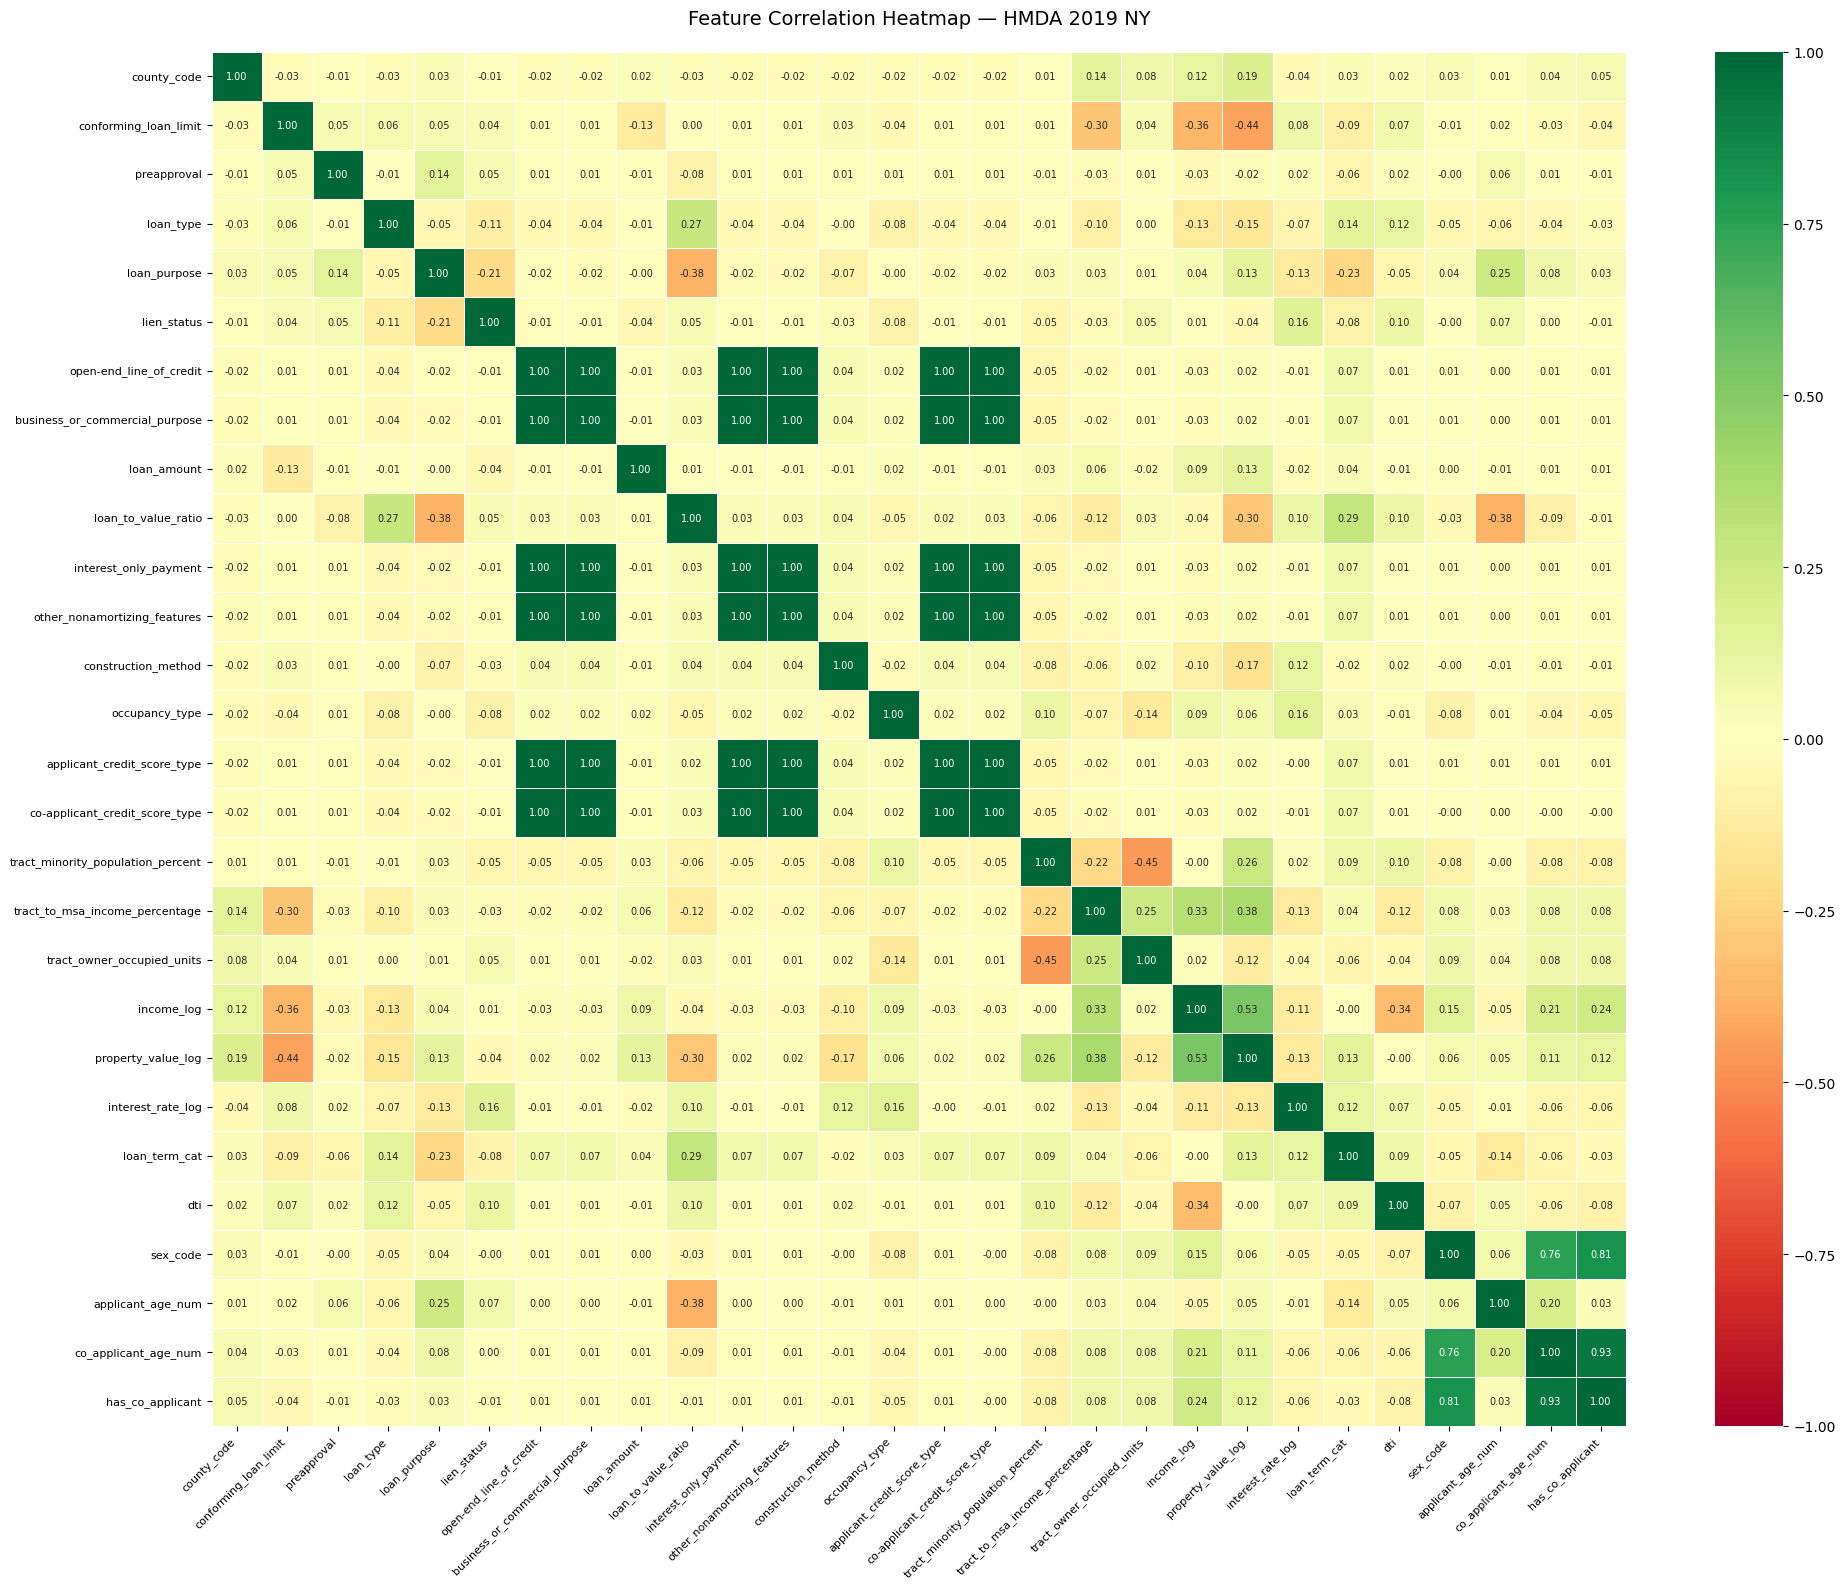


High correlations between features (|r| > 0.5):
Feature 1                           Feature 2                                  r
────────────────────────────────────────────────────────────────────────────────
open-end_line_of_credit             business_or_commercial_purpose        1.0000
open-end_line_of_credit             interest_only_payment                 0.9999
open-end_line_of_credit             other_nonamortizing_features          0.9999
open-end_line_of_credit             applicant_credit_score_type           0.9998
open-end_line_of_credit             co-applicant_credit_score_type        0.9998
business_or_commercial_purpose      interest_only_payment                 0.9999
business_or_commercial_purpose      other_nonamortizing_features          0.9999
business_or_commercial_purpose      applicant_credit_score_type           0.9998
business_or_commercial_purpose      co-applicant_credit_score_type        0.9998
interest_only_payment               other_nonamortizing_feat

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Exclude target and sensitive attributes from heatmap for cleanliness
# But include them to see correlations

import os
os.makedirs('/content/figures', exist_ok=True)

plt.savefig('/content/figures/hmda2019_correlation_heatmap.png', dpi=150, bbox_inches='tight')



corr_matrix = df_2019.drop(columns=['loan_approved', 'race_binary',
                                     'ethnicity_binary']).corr()

plt.figure(figsize=(20, 16))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={'size': 7}
)
plt.title('Feature Correlation Heatmap — HMDA 2019 NY', fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('/content/figures/hmda2019_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Also print high correlations (>0.5) between features
print('\nHigh correlations between features (|r| > 0.5):')
print(f'{"Feature 1":<35} {"Feature 2":<35} {"r":>8}')
print(f'{"─"*80}')
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.5:
            print(f'{corr_matrix.columns[i]:<35} {corr_matrix.columns[j]:<35} {r:>8.4f}')

In [ ]:
# ══════════════════════════════════════════════════════════════════
# COST FRAMEWORK — Align cost metadata to final cleaned dataset
# Rows were dropped in cells 23 (action=8), 38 (Joint), 61 (conf=U)
# This re-aligns by index so cost_meta rows == df_2019 rows exactly
# ══════════════════════════════════════════════════════════════════
cost_meta = df_cost_raw.loc[df_2019.index].copy()

# Clean interest_rate: fill nulls with median, cap outliers
RATE_MEDIAN = cost_meta['interest_rate'].median()
cost_meta['interest_rate'] = (
    cost_meta['interest_rate']
    .fillna(RATE_MEDIAN)
    .clip(upper=15.0)           # cap data-entry errors
)

# Convert loan_term months → years
cost_meta['loan_term_years'] = cost_meta['loan_term'] / 12

# Verify alignment
assert len(cost_meta) == len(df_2019), "Index mismatch — check row drops"
assert cost_meta.index.equals(df_2019.index), "Index order mismatch"

print(f'cost_meta shape: {cost_meta.shape}  ✅ aligned to df_2019')
print(cost_meta.describe().round(2))

cost_meta shape: (477937, 5)  ✅ aligned to df_2019
        loan_amount  interest_rate  loan_term  property_value  loan_term_years
count  4.779370e+05      477937.00  461380.00       460934.00        461380.00
mean   3.494917e+05           3.06     312.10       606264.82            26.01
std    2.079237e+06           0.66      79.17       754089.71             6.60
min    5.000000e+03           0.50       1.00         5000.00             0.08
25%    1.350000e+05           2.75     240.00       245000.00            20.00
50%    2.550000e+05           2.99     360.00       455000.00            30.00
75%    4.450000e+05           3.25     360.00       715000.00            30.00
max    1.409715e+09          15.00     480.00     80005000.00            40.00


In [ ]:
# ── 1. Interest rate — fill nulls with median, cap outliers ──────
RATE_MEDIAN = cost_meta['interest_rate'].median()
cost_meta['interest_rate'] = (
    cost_meta['interest_rate']
    .fillna(RATE_MEDIAN)
    .clip(upper=15.0)
)

# ── 2. Loan term — fill nulls with mode (360), cap at 30yr ───────
TERM_MODE = cost_meta['loan_term'].mode()[0]
cost_meta['loan_term'] = (
    cost_meta['loan_term']
    .fillna(TERM_MODE)
    .clip(upper=360)
)
cost_meta['loan_term_years'] = cost_meta['loan_term'] / 12

# ── 3. Loan amount — cap at 99th percentile ───────────────────────
p99_loan = cost_meta['loan_amount'].quantile(0.99)
cost_meta['loan_amount'] = cost_meta['loan_amount'].clip(upper=p99_loan)

# ── 4. Property Value — fill nulls with median ────────────────────
# Note: This is after outlier removal, which happened before parking.
PV_MEDIAN = cost_meta['property_value'].median()
cost_meta['property_value'] = cost_meta['property_value'].fillna(PV_MEDIAN)

# ── 5. Verify ─────────────────────────────────────────────────────
assert cost_meta.isnull().sum().sum() == 0, "Nulls remain in cost_meta!"
assert len(cost_meta) == len(df_2019), "Row count mismatch!"

print(f'Nulls: {cost_meta.isnull().sum().sum()} ✅')
print(f'Shape: {cost_meta.shape} ✅')
print(cost_meta.describe().round(2))

Nulls: 0 ✅
Shape: (477937, 5) ✅
       loan_amount  interest_rate  loan_term  property_value  loan_term_years
count    477937.00      477937.00  477937.00       477937.00        477937.00
mean     335448.18           3.06     313.58       600883.45            26.13
std      298408.49           0.66      78.05       741084.38             6.50
min        5000.00           0.50       1.00         5000.00             0.08
25%      135000.00           2.75     240.00       245000.00            20.00
50%      255000.00           2.99     360.00       455000.00            30.00
75%      445000.00           3.25     360.00       705000.00            30.00
max     1805000.00          15.00     360.00     80005000.00            30.00


In [ ]:
# ── Save to Notebook 2 ────────────────────────────────────────────
df_2019.to_parquet('df_2019_cleaned.parquet', index=True)   # ← index=True
cost_meta.to_parquet('cost_meta.parquet', index=True)        # ← index=True

# Also save race separately — it travels alongside, never inside X
race_series = df_2019['race_binary'].copy()
race_series.to_frame().to_parquet('race_meta.parquet', index=True)

print("Saved:")
print(f"  df_2019_cleaned : {df_2019.shape}")
print(f"  cost_meta       : {cost_meta.shape}")
print(f"  race_meta       : {race_series.shape}")

Saved:
  df_2019_cleaned : (477937, 31)
  cost_meta       : (477937, 5)
  race_meta       : (477937,)
